# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

# Ruta al archivo (desde la raíz del repo)
ruta = "../data/raw/Telco_customer_churn.csv"

df = pd.read_csv(ruta)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
# Número de filas y columnas
print("numero de filas y columnas")
df.shape

# Información general: tipos y nulos
print("tipos y nulos")
df.info()

# Tipos de dato por columna
print("tipos de dato por columna")
df.dtypes

numero de filas y columnas
tipos y nulos
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-nul

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [9]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df["Total Charges"].dtype

dtype('float64')

### Paso 1: Carga de datos – Respuestas

El archivo tiene 7043 filas y 33 columnas.

Las columnas numéricas son principalmente: Count, Zip Code, Latitude, Longitude, Tenure Months, Monthly Charges, Total Charges, Churn Value, Churn Score y CLTV.

Las demás columnas son de tipo texto o categóricas, por ejemplo: CustomerID, Country, State, City, Lat Long, Gender, Senior Citizen, Partner, Dependents, Phone Service, Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Contract, Paperless Billing, Payment Method, Churn Label y Churn Reason.

En general los tipos de dato tienen sentido: identificadores y categorías están como texto, y las cantidades (meses, cargos, puntuaciones) están como números. Algunas columnas que son “sí/no” podrían tratarse como categóricas o booleanas, pero tal como están se pueden trabajar sin problema.

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [10]:
# Columnas numéricas y categóricas
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Columnas numéricas:\n", num_cols)
print("\nColumnas categóricas:\n", cat_cols)

# Resumen de variables numéricas: rangos, medias, etc.
display(df[num_cols].describe().T)

# Número de valores únicos por columna
nunique_cols = df.nunique().sort_values()
print("\nValores únicos por columna:")
display(nunique_cols)

# Posibles variables que NO varían (constantes)
cols_constantes = nunique_cols[nunique_cols == 1]
print("\nColumnas que solo toman un valor:")
display(cols_constantes)

# Posibles claves primarias (tantos valores únicos como filas)
n_filas = len(df)
posibles_id = nunique_cols[nunique_cols == n_filas]
print("\nPosibles claves primarias / identificadores únicos:")
display(posibles_id)

# Cardinalidad de variables categóricas
cardinalidad_cat = df[cat_cols].nunique().sort_values(ascending=False)
print("\nCardinalidad de variables categóricas:")
display(cardinalidad_cat)

Columnas numéricas:
 Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score',
       'CLTV'],
      dtype='object')

Columnas categóricas:
 Index(['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender',
       'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000



Valores únicos por columna:


Count                   1
Country                 1
State                   1
Phone Service           2
Dependents              2
Partner                 2
Senior Citizen          2
Gender                  2
Churn Value             2
Paperless Billing       2
Churn Label             2
Multiple Lines          3
Internet Service        3
Online Backup           3
Online Security         3
Tech Support            3
Contract                3
Streaming Movies        3
Streaming TV            3
Device Protection       3
Payment Method          4
Churn Reason           20
Tenure Months          73
Churn Score            85
City                 1129
Monthly Charges      1585
Longitude            1651
Latitude             1652
Lat Long             1652
Zip Code             1652
CLTV                 3438
Total Charges        6530
CustomerID           7043
dtype: int64


Columnas que solo toman un valor:


Count      1
Country    1
State      1
dtype: int64


Posibles claves primarias / identificadores únicos:


CustomerID    7043
dtype: int64


Cardinalidad de variables categóricas:


CustomerID           7043
Lat Long             1652
City                 1129
Churn Reason           20
Payment Method          4
Online Backup           3
Multiple Lines          3
Contract                3
Streaming Movies        3
Streaming TV            3
Internet Service        3
Device Protection       3
Tech Support            3
Online Security         3
Gender                  2
Dependents              2
Partner                 2
Senior Citizen          2
Phone Service           2
Paperless Billing       2
Churn Label             2
Country                 1
State                   1
dtype: int64

### Paso 2: Exploración inicial de los datos – Respuestas

Los rangos de las variables numéricas son razonables para este problema: los meses de permanencia van de 0 a 72, los cobros mensuales y totales están en montos lógicos y las coordenadas geográficas encajan con ubicaciones reales.

Hay columnas que prácticamente no aportan información porque siempre toman el mismo valor, como Count, Country y State. También se observa que CustomerID tiene un valor distinto para cada fila, por lo que funciona como identificador único de cada cliente.

Dentro de las variables de texto, las que tienen muchos valores distintos son CustomerID, Lat Long, City y Churn Reason. Las demás tienen pocas categorías y son más fáciles de manejar.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [11]:
# 1. Identificar columnas a descartar según las instrucciones
# - variables con un solo valor
cols_un_valor = df.columns[df.nunique() == 1]
print("Columnas con un solo valor:")
print(cols_un_valor)

# - posibles claves primarias
n_filas = len(df)
cols_id = df.columns[df.nunique() == n_filas]
print("\nPosibles claves primarias:")
print(cols_id)

# - City y Lat Long (explícitamente indicadas)
cols_extra = ["City", "Lat Long"]

cols_a_descartar = list(set(cols_un_valor) | set(cols_id) | set(cols_extra))
print("\nColumnas a descartar:")
print(cols_a_descartar)

# 2. Crear un dataframe sin esas columnas
df_reducido = df.drop(columns=cols_a_descartar)
df_reducido.shape

Columnas con un solo valor:
Index(['Count', 'Country', 'State'], dtype='object')

Posibles claves primarias:
Index(['CustomerID'], dtype='object')

Columnas a descartar:
['CustomerID', 'City', 'Count', 'State', 'Lat Long', 'Country']


(7043, 27)

In [12]:
# Variables con valores nulos y su proporción
na_prop = df_reducido.isna().mean().sort_values(ascending=False)
print("Proporción de valores nulos por columna:")
display(na_prop[na_prop > 0])

# Registros duplicados
duplicados = df_reducido.duplicated().sum()
print("\nNúmero de registros duplicados:", duplicados)

# Revisar posibles problemas de formateo en algunas columnas categóricas
cat_cols_reducido = df_reducido.select_dtypes(include=["object"]).columns

for col in ["Payment Method", "Contract", "Churn Label", "Churn Reason"]:
    if col in cat_cols_reducido:
        print(f"\nColumna: {col}")
        display(df_reducido[col].value_counts().head(10))

Proporción de valores nulos por columna:


Churn Reason     0.734630
Total Charges    0.001562
dtype: float64


Número de registros duplicados: 0

Columna: Payment Method


Payment Method
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


Columna: Contract


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


Columna: Churn Label


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


Columna: Churn Reason


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

### Paso 3: Datos duplicados, nulos y formateo – Respuestas

Siguiendo las indicaciones, se eliminaron las columnas con un solo valor (Count, Country y State), la clave primaria CustomerID y las columnas City y Lat Long. El conjunto de datos reducido sigue teniendo 7043 filas, pero con menos columnas.

Al revisar los valores nulos, casi todas las columnas están completas. La razón principal de churn (Churn Reason) tiene muchos valores faltantes, porque solo se llena cuando el cliente se va. Total Charges tiene una proporción muy pequeña de datos faltantes.

No se encontraron filas duplicadas. En cuanto al formato, los textos de columnas como Payment Method, Contract y Churn Label están bien escritos y consistentes. Churn Reason es un campo de texto libre con varias descripciones distintas, pero no presenta problemas graves de formato.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

Columnas numéricas en df_reducido:
Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')


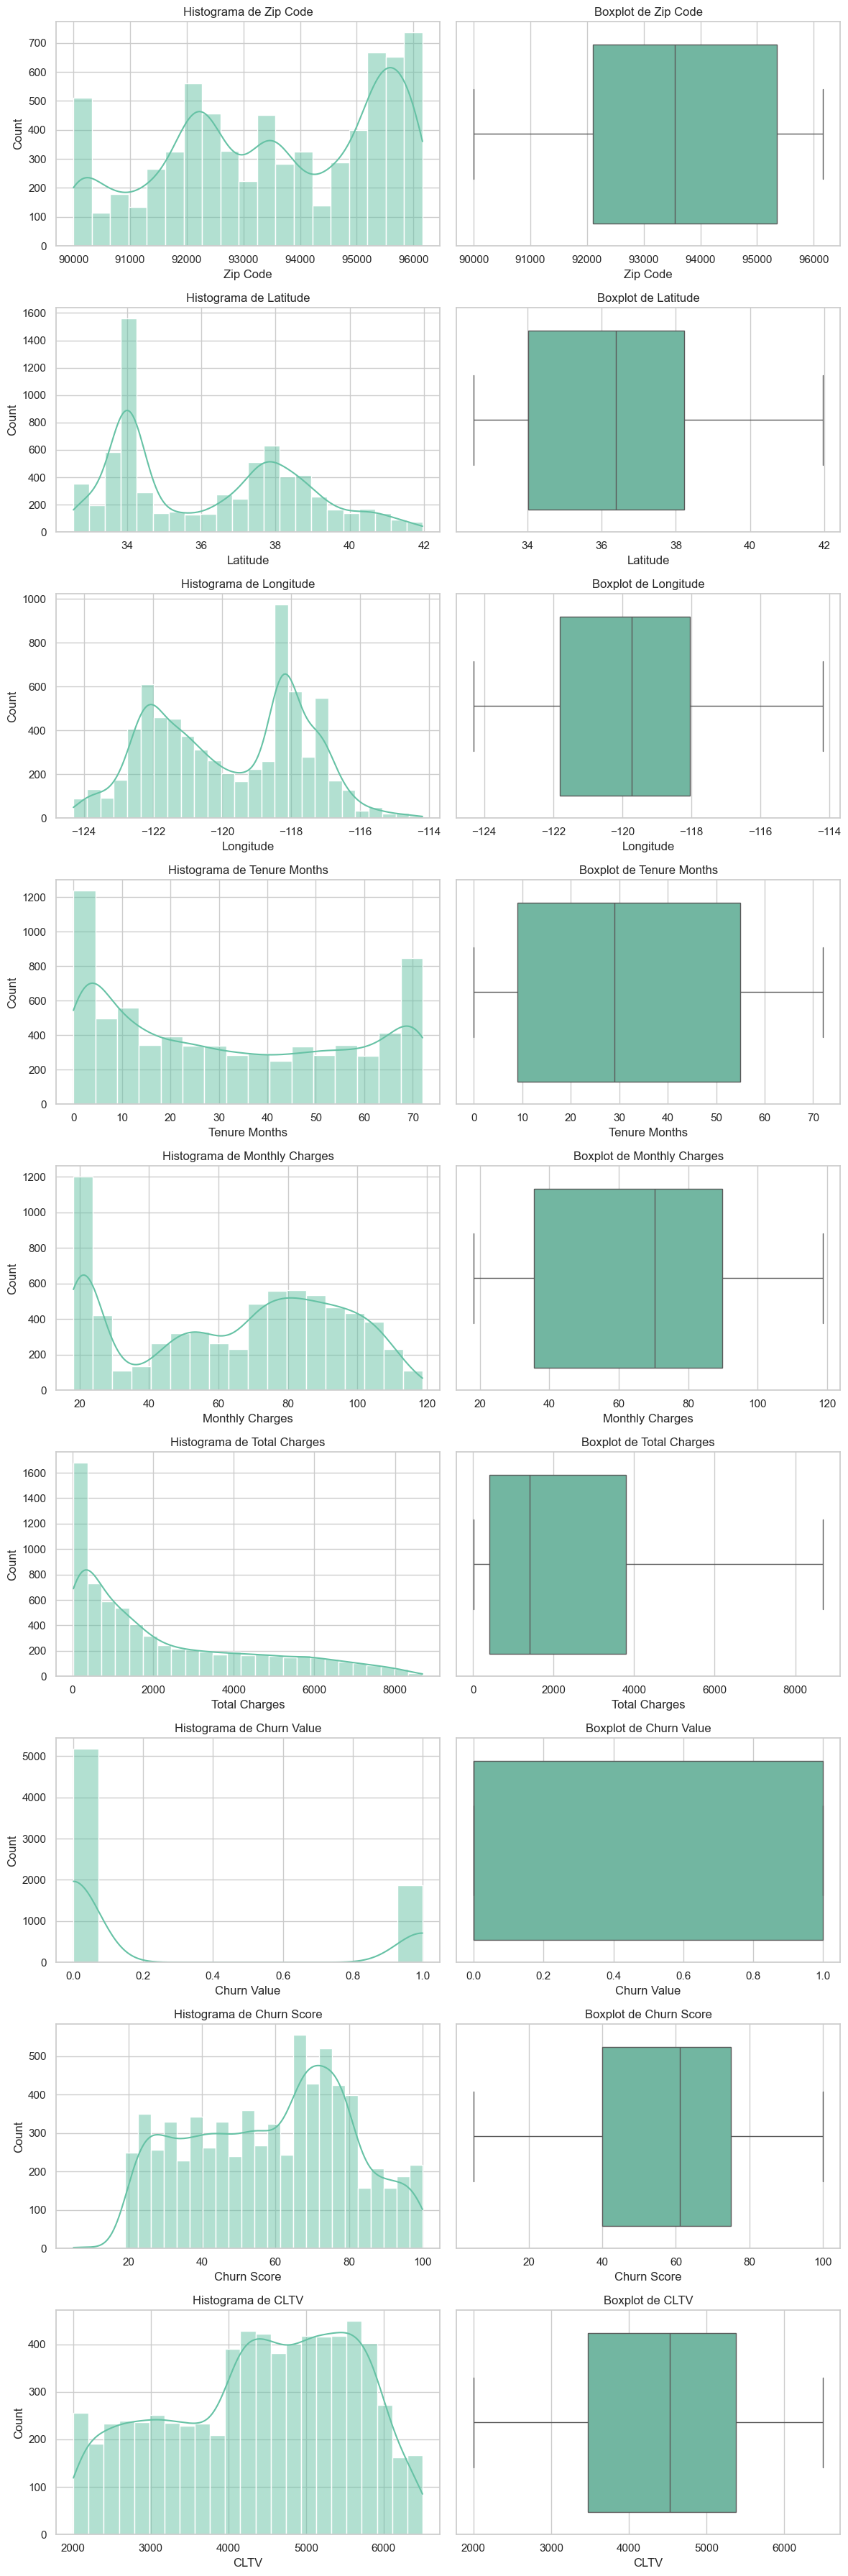

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2")

# Columnas numéricas del dataframe reducido
num_cols_red = df_reducido.select_dtypes(include=["number"]).columns
print("Columnas numéricas en df_reducido:")
print(num_cols_red)

# Histogramas + KDE y boxplots para ver forma y outliers
fig, axes = plt.subplots(nrows=len(num_cols_red), ncols=2, figsize=(12, 4 * len(num_cols_red)))

for i, col in enumerate(num_cols_red):
    # Histograma + curva de densidad
    sns.histplot(data=df_reducido, x=col, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Histograma de {col}")
    
    # Boxplot para detectar outliers
    sns.boxplot(data=df_reducido, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

### Paso 4: Análisis de variables cuantitativas – Respuestas

Las variables numéricas no siguen una distribución perfectamente normal. Tenure Months, Monthly Charges y sobre todo Total Charges están sesgadas hacia la derecha, con muchos clientes en valores bajos o medios y pocos en valores muy altos. Churn Score y CLTV también muestran formas alejadas de la campana clásica.

En los diagramas de caja se ven valores atípicos sobre todo en Total Charges, Monthly Charges y CLTV, donde aparecen clientes con montos mucho mayores que el resto. En Tenure Months y Churn Score también hay puntos extremos en los bordes del rango, aunque siguen siendo valores posibles dentro del contexto del negocio.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [14]:
# Variables categóricas en el dataframe reducido
cat_cols_red = df_reducido.select_dtypes(include=["object"]).columns
print("Columnas categóricas en df_reducido:")
print(cat_cols_red)

# Resumen de frecuencias
for col in cat_cols_red:
    print(f"\n===== {col} =====")
    display(df_reducido[col].value_counts())
    print("Número de categorías:", df_reducido[col].nunique())

Columnas categóricas en df_reducido:
Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')

===== Gender =====


Gender
Male      3555
Female    3488
Name: count, dtype: int64

Número de categorías: 2

===== Senior Citizen =====


Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64

Número de categorías: 2

===== Partner =====


...

Número de categorías: 4

===== Churn Label =====


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Número de categorías: 2

===== Churn Reason =====


Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Service dissatisfaction                       89
Lack of self-service on Website               88
Extra data charges                            57
Moved                                         53
Lack of affordable download/upload speed      44
Limited range of services                     44
Long distance charges                         44
Poor expertise of phone support               20
Poor expertise of online support              19
Deceased                                       6
Name: c

Número de categorías: 20


### Paso 5: Análisis de variables cualitativas – Respuesta

Las variables categóricas más simples, como Gender, Senior Citizen, Partner, Dependents, Phone Service, Paperless Billing y Churn Label, tienen solo dos categorías y están relativamente balanceadas, aunque en varios casos una de las categorías es más frecuente que la otra.

Otras columnas tienen tres o cuatro categorías, como Multiple Lines, Internet Service, Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, Streaming Movies, Contract y Payment Method. En general sus categorías son claras y tienen cantidades razonables de observaciones.

La única variable realmente de alta cardinalidad en el conjunto reducido es Churn Reason, con veinte posibles motivos distintos de cancelación. Dentro de esta columna hay algunas razones muy poco frecuentes, como el caso Deceased y otros motivos con muy pocos registros, que se pueden considerar categorías poco comunes o atípicas.

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


In [15]:
target = "Churn Value"

# Columnas numéricas y categóricas del dataframe reducido
num_cols_red = df_reducido.select_dtypes(include=["number"]).columns
cat_cols_red = df_reducido.select_dtypes(include=["object"]).columns

print("Numéricas:", num_cols_red)
print("Categóricas:", cat_cols_red)

Numéricas: Index(['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges',
       'Total Charges', 'Churn Value', 'Churn Score', 'CLTV'],
      dtype='object')
Categóricas: Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Churn Label', 'Churn Reason'],
      dtype='object')


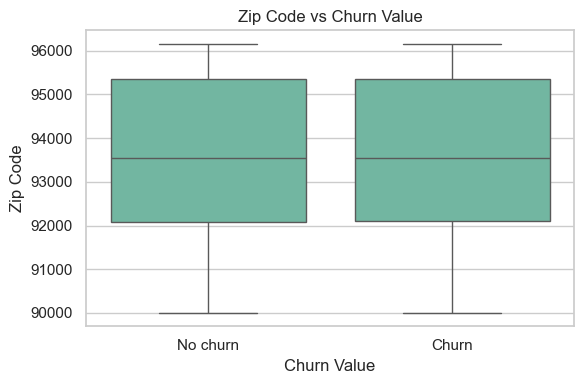

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,93518.212215,1868.429496,90001.0,92091.0,93551.0,95345.75,96148.0
1,1869.0,93532.352595,1858.939970,90001.0,92105.0,93554.0,95358.00,96161.0


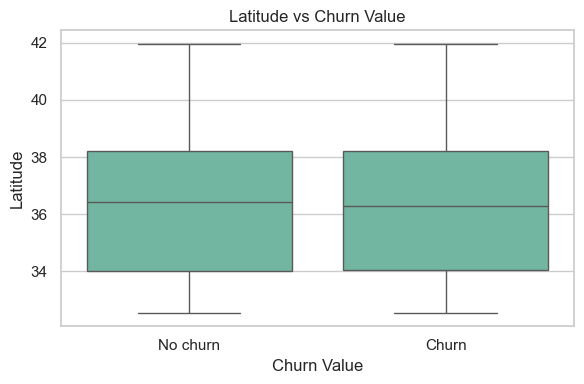

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,36.287436,2.449340,32.555828,34.029076,36.414414,38.227285,41.962127
1,1869.0,36.268614,2.473911,32.555828,34.038983,36.298780,38.200231,41.962127


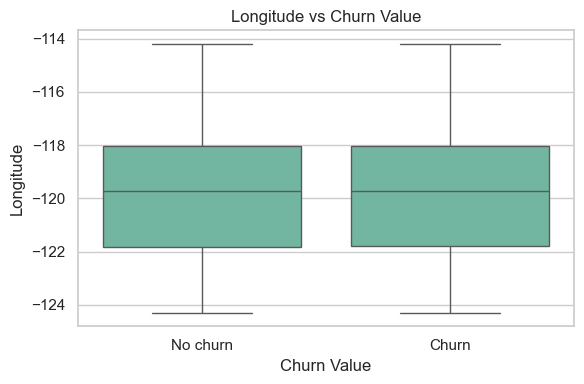

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,-119.804838,2.156210,-124.301372,-121.823565,-119.739935,-118.049237,-114.192901
1,1869.0,-119.782388,2.163024,-124.301372,-121.799917,-119.711868,-118.020188,-114.192901


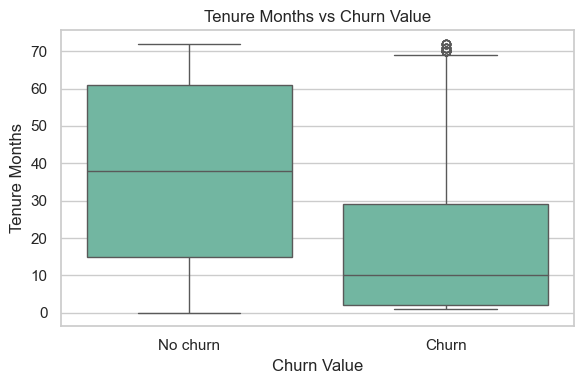

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


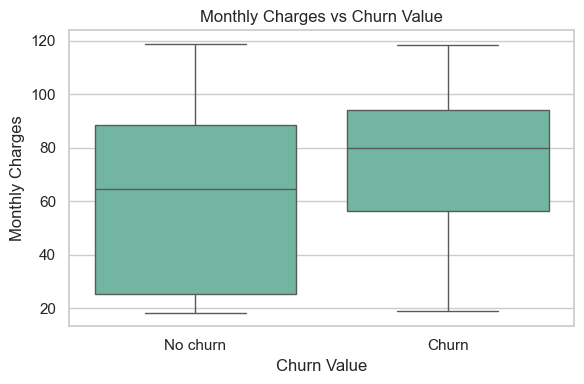

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
1,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


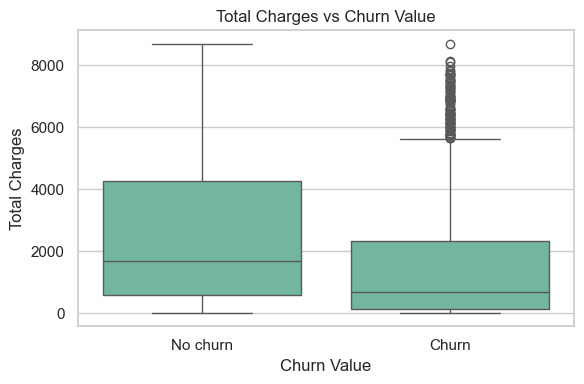

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
1,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


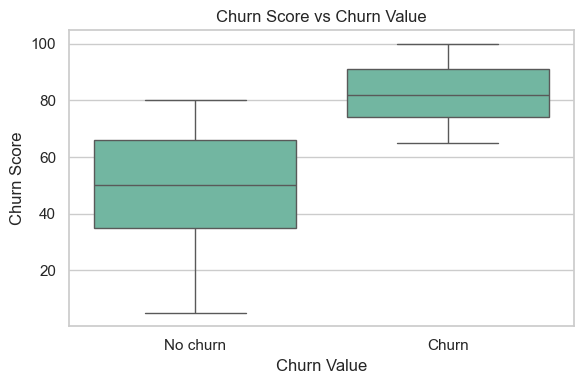

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
1,1869.0,82.510433,10.328570,65.0,74.0,82.0,91.0,100.0


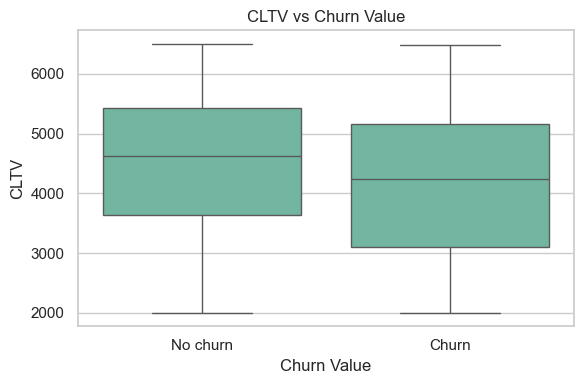

,count,mean,std,min,25%,50%,75%,max
Churn Value,,,,,,,,
0,5174.0,4490.921337,1167.703198,2003.0,3643.75,4620.0,5434.75,6500.0
1,1869.0,4149.414660,1189.370707,2003.0,3101.00,4238.0,5166.00,6484.0


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols_red:
    if col == target:
        continue
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df_reducido, x=target, y=col)
    plt.title(f"{col} vs {target}")
    plt.xticks([0,1], ["No churn", "Churn"])
    plt.tight_layout()
    plt.show()

    # Estadísticos por grupo
    display(df_reducido.groupby(target)[col].describe())


===== Gender vs Churn Value =====


Churn Value,0,1
Gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


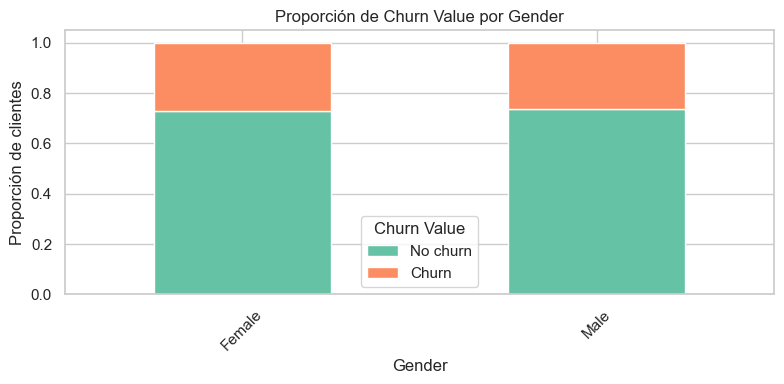


===== Senior Citizen vs Churn Value =====


Churn Value,0,1
Senior Citizen,,
No,0.763938,0.236062
Yes,0.583187,0.416813


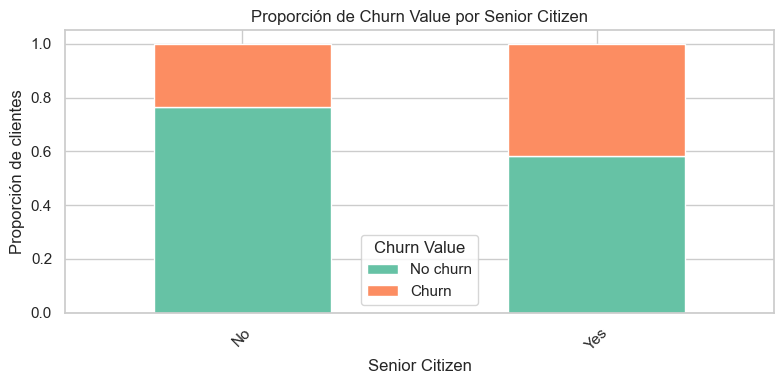


===== Partner vs Churn Value =====


Churn Value,0,1
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


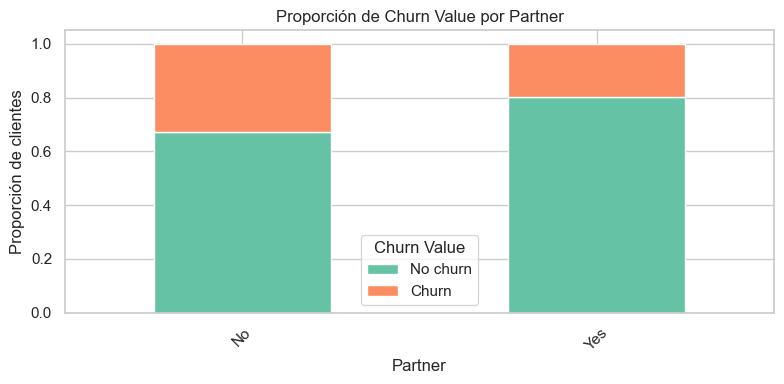


===== Dependents vs Churn Value =====


Churn Value,0,1
Dependents,,
No,0.674483,0.325517
Yes,0.934849,0.065151


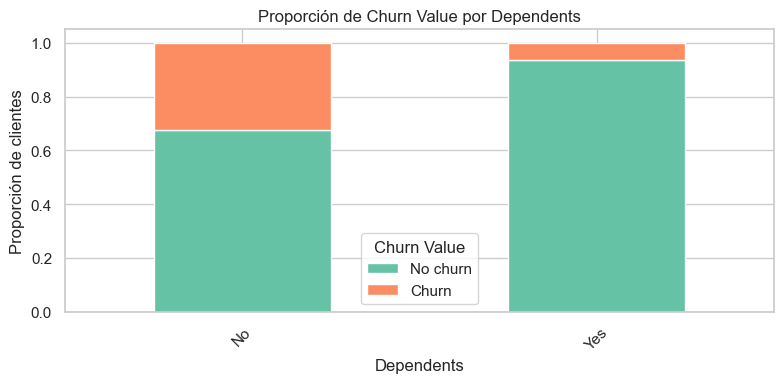


===== Phone Service vs Churn Value =====


Churn Value,0,1
Phone Service,,
No,0.750733,0.249267
Yes,0.732904,0.267096


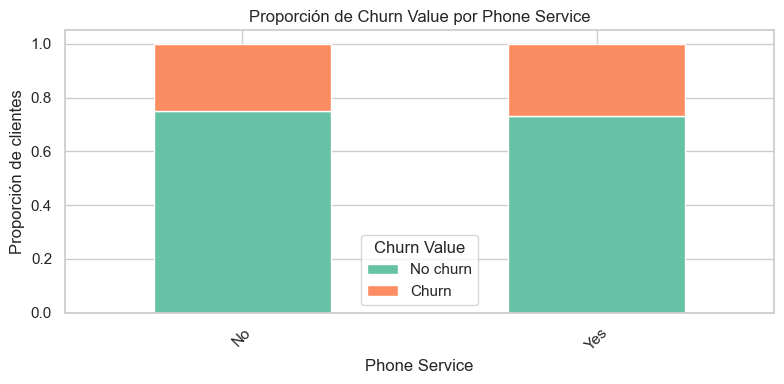


===== Multiple Lines vs Churn Value =====


Churn Value,0,1
Multiple Lines,,
No,0.749558,0.250442
No phone service,0.750733,0.249267
Yes,0.713901,0.286099


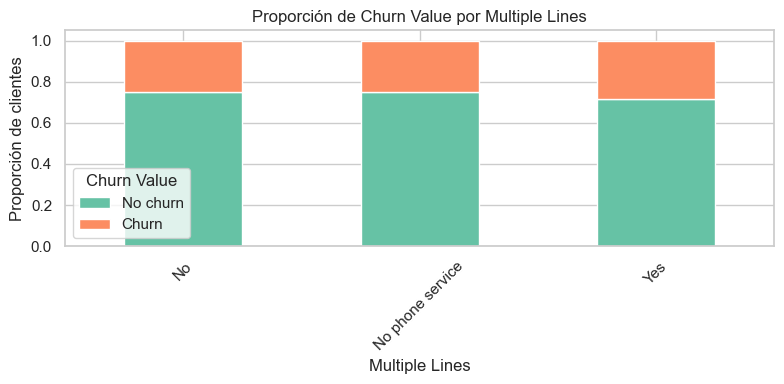


===== Internet Service vs Churn Value =====


Churn Value,0,1
Internet Service,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


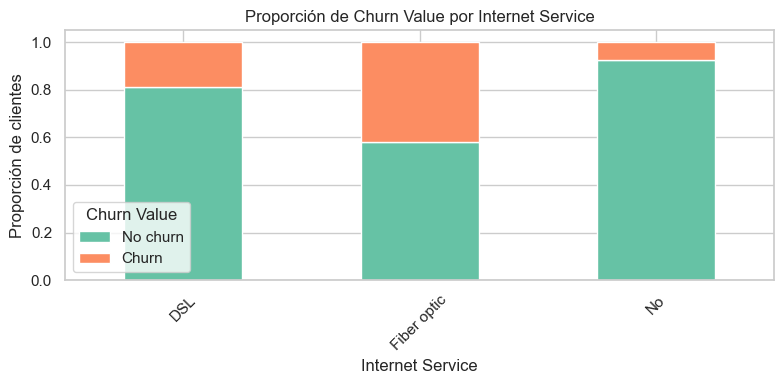


===== Online Security vs Churn Value =====


Churn Value,0,1
Online Security,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


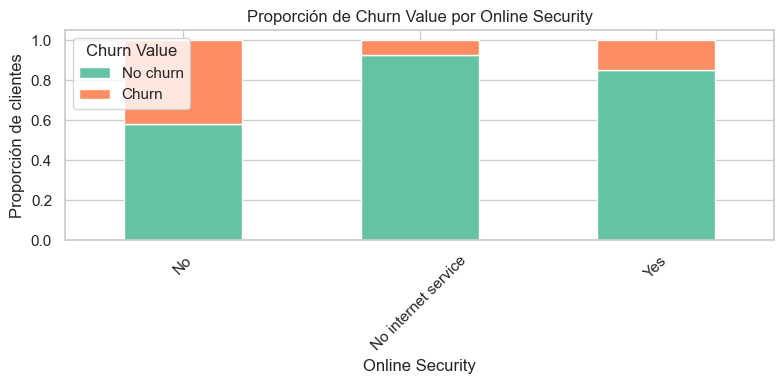


===== Online Backup vs Churn Value =====


Churn Value,0,1
Online Backup,,
No,0.600712,0.399288
No internet service,0.925950,0.074050
Yes,0.784685,0.215315


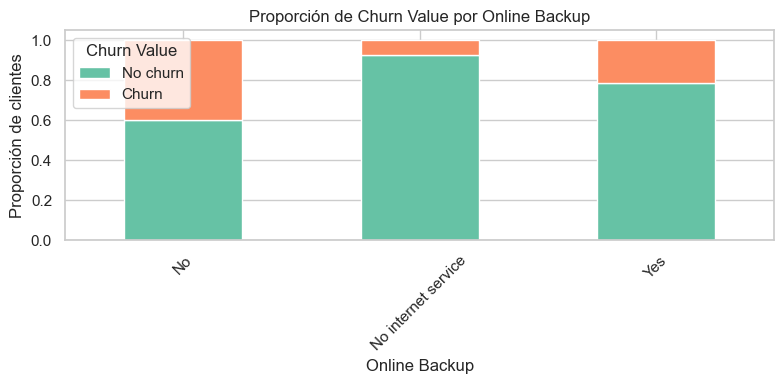


===== Device Protection vs Churn Value =====


Churn Value,0,1
Device Protection,,
No,0.608724,0.391276
No internet service,0.925950,0.074050
Yes,0.774979,0.225021


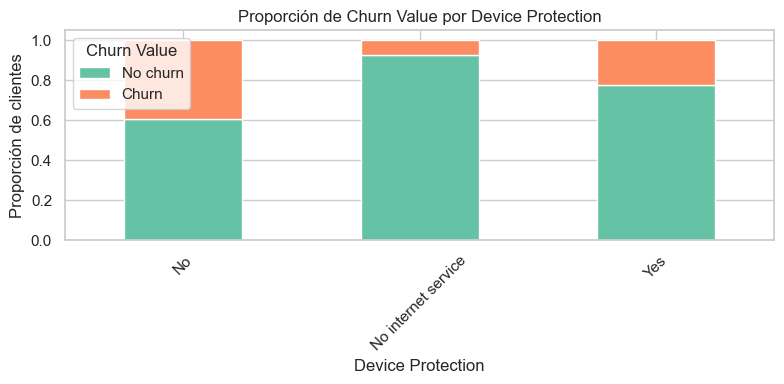


===== Tech Support vs Churn Value =====


Churn Value,0,1
Tech Support,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


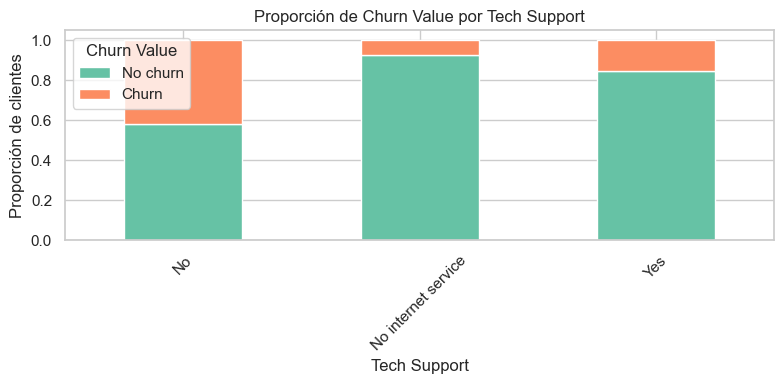


===== Streaming TV vs Churn Value =====


Churn Value,0,1
Streaming TV,,
No,0.664769,0.335231
No internet service,0.925950,0.074050
Yes,0.699298,0.300702


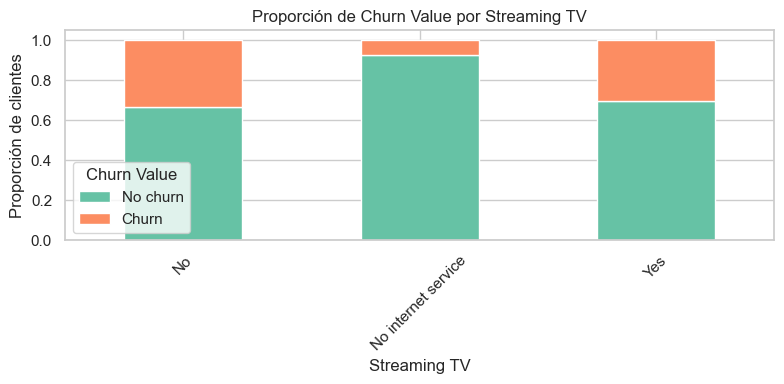


===== Streaming Movies vs Churn Value =====


Churn Value,0,1
Streaming Movies,,
No,0.663196,0.336804
No internet service,0.925950,0.074050
Yes,0.700586,0.299414


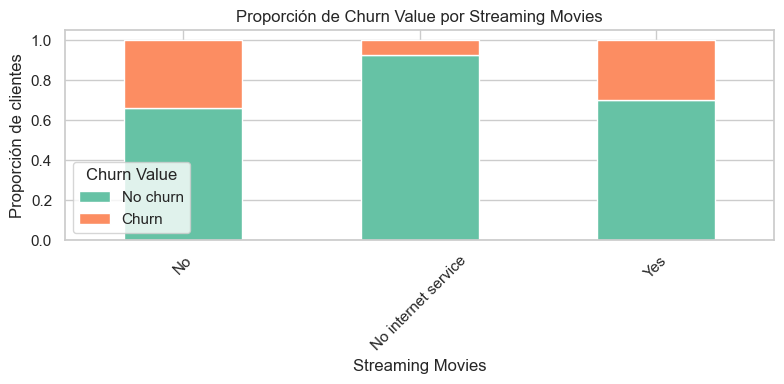


===== Contract vs Churn Value =====


Churn Value,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


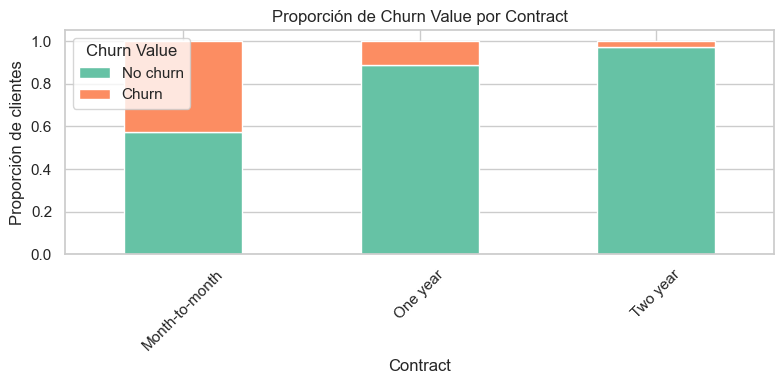


===== Paperless Billing vs Churn Value =====


Churn Value,0,1
Paperless Billing,,
No,0.836699,0.163301
Yes,0.664349,0.335651


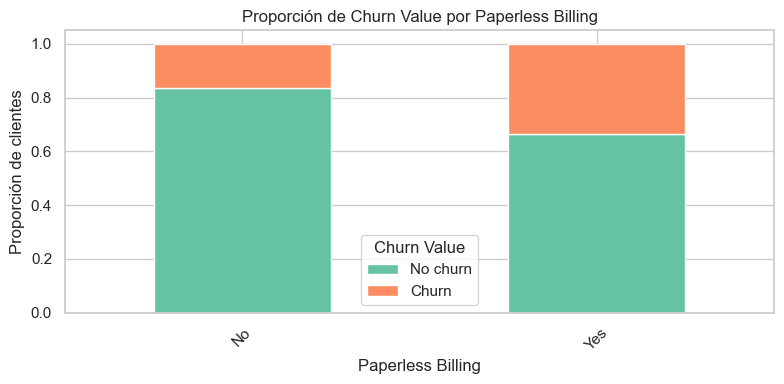


===== Payment Method vs Churn Value =====


Churn Value,0,1
Payment Method,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


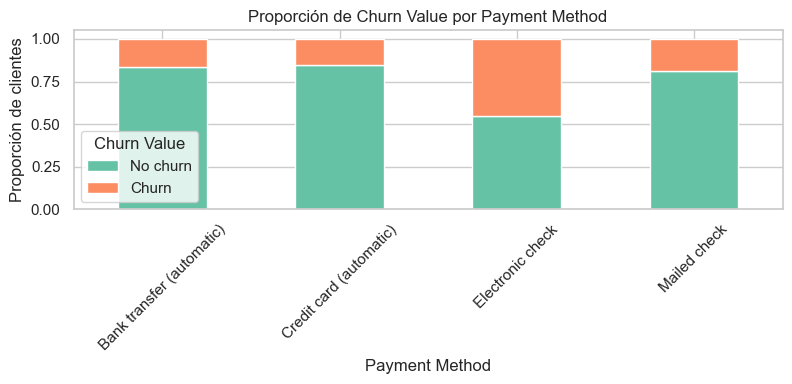


===== Churn Label vs Churn Value =====


Churn Value,0,1
Churn Label,,
No,1.0,0.0
Yes,0.0,1.0


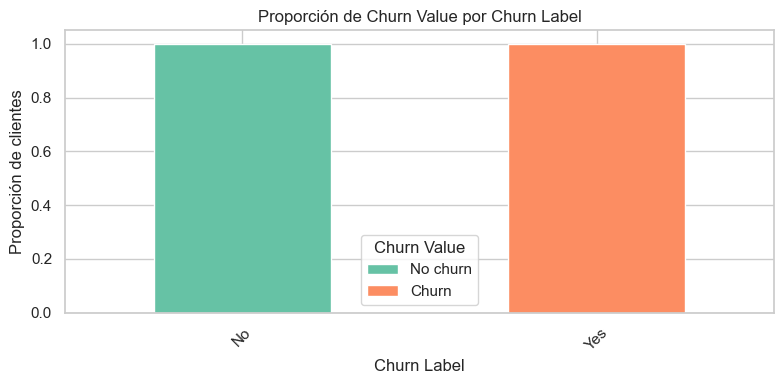


===== Churn Reason vs Churn Value =====


Churn Value,1
Churn Reason,
Attitude of service provider,1.0
Attitude of support person,1.0
Competitor had better devices,1.0
Competitor made better offer,1.0
Competitor offered higher download speeds,1.0
Competitor offered more data,1.0
Deceased,1.0
Don't know,1.0
Extra data charges,1.0


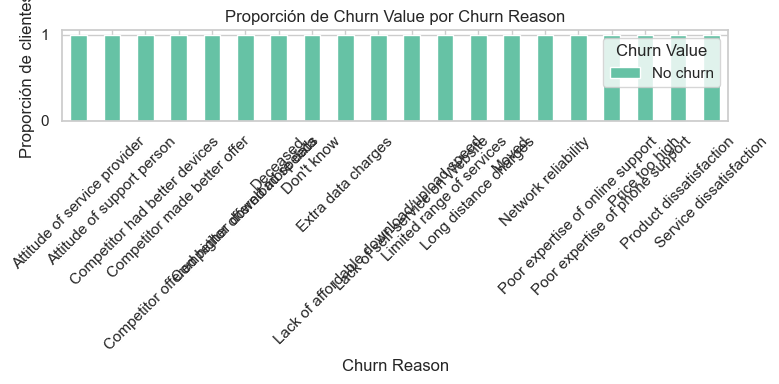

In [17]:
for col in cat_cols_red:
    print(f"\n===== {col} vs {target} =====")
    tabla = pd.crosstab(df_reducido[col], df_reducido[target], normalize="index")
    display(tabla)

    tabla.plot(kind="bar", stacked=True, figsize=(8,4))
    plt.title(f"Proporción de {target} por {col}")
    plt.ylabel("Proporción de clientes")
    plt.legend(title=target, labels=["No churn", "Churn"])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Paso 6: Análisis bivariado con la variable objetivo – Respuesta

Al comparar clientes que se quedan con los que se van, se observa que quienes hacen churn llevan menos tiempo con la empresa, pagan cargos mensuales más altos y tienen un Churn Score medio mucho mayor. El valor total facturado suele ser menor en los que se van, en parte porque han permanecido menos tiempo.

En cuanto a las variables categóricas, hay patrones claros. Los contratos mes a mes tienen mucha más probabilidad de churn que los contratos de uno o dos años. Los clientes con internet de tipo fibra óptica presentan más churn que quienes tienen DSL o no tienen internet. También se ve menos churn en clientes que cuentan con servicios adicionales como seguridad en línea, soporte técnico o copias de respaldo.

La facturación electrónica y el pago por electronic check se asocian con una proporción más alta de churn, mientras que los pagos automáticos por banco o tarjeta y la facturación física muestran menos salidas. Tener pareja o dependientes también parece estar relacionado con una menor probabilidad de abandono.

En cambio, variables como el código postal, las coordenadas geográficas, el género o el simple hecho de tener o no servicio telefónico no muestran diferencias tan marcadas entre clientes que se quedan y los que se van. En resumen, las variables más útiles para predecir churn son las relacionadas con el tiempo de permanencia, el nivel de cobro, el tipo de contrato, el tipo de servicio de internet y algunos servicios y formas de pago asociadas al cliente.